# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Muhammad Farid Wijdan | 5054251042 |

## Deskripsi Tugas
Di tugas ini saya membangun model ANN (Multi-Layer Perceptron) Classifier untuk memprediksi churn pelanggan Telco.

Dataset: https://www.kaggle.com/datasets/blastchar/telco-customer-churn (data pelanggan, targetnya kolom `Churn`: Yes = berhenti, No = bertahan)

Tujuannya biar paham praktik ANN, khususnya:
1. Bedanya fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) ke overfitting


# 1. Persiapan Dataset dan Eksplorasi Awal


In [1]:
import warnings
warnings.filterwarnings('ignore')  # biar warning konvergensi tidak memenuhi output

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
# load dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print('Jumlah baris:', df.shape[0])
print('Jumlah kolom:', df.shape[1])
df.head()
df.info()
df.describe(include='all')
print('\nJumlah missing value per kolom:')
print(df.isnull().sum().sum())

Jumlah baris: 7043
Jumlah kolom: 21
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling 

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Persentase:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


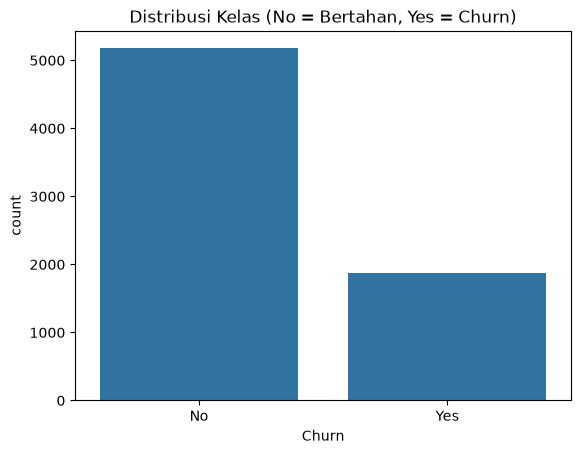

In [3]:
# distribusi kelas target (Yes = churn/berhenti, No = bertahan)
print(df['Churn'].value_counts())
print('\nPersentase:')
print((df['Churn'].value_counts(normalize=True) * 100).round(2))

sns.countplot(x='Churn', data=df)
plt.title('Distribusi Kelas (No = Bertahan, Yes = Churn)')
plt.show()
# yang churn sekitar seperempatnya, agak imbalanced tapi tidak parah

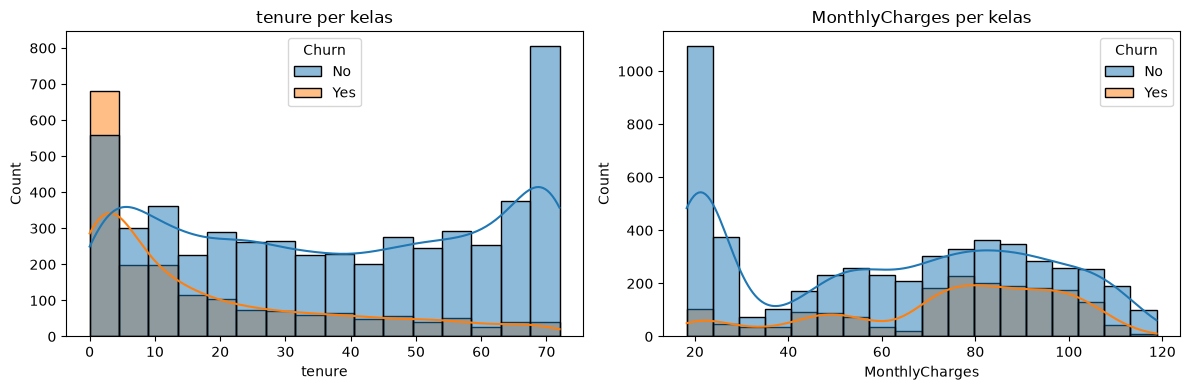

In [4]:
# lihat sebaran 2 fitur numerik dibedakan per kelas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, ax=axes[0])
axes[0].set_title('tenure per kelas')
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, ax=axes[1])
axes[1].set_title('MonthlyCharges per kelas')
plt.tight_layout()
plt.show()
# pelanggan baru (tenure kecil) kelihatan lebih banyak yang churn

## EDA tambahan: churn rate per jenis kontrak dan korelasi fitur numerik


Churn              No    Yes
Contract                    
Month-to-month  0.573  0.427
One year        0.887  0.113
Two year        0.972  0.028


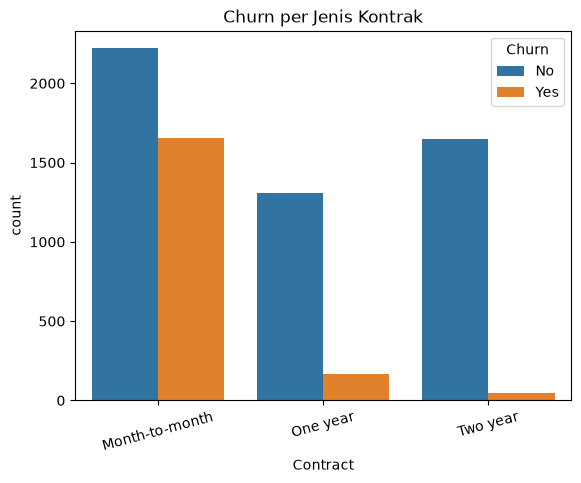

In [5]:
# churn rate per Contract: pelanggan kontrak bulanan vs tahunan
print(pd.crosstab(df['Contract'], df['Churn'], normalize='index').round(3))

sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn per Jenis Kontrak')
plt.xticks(rotation=15)
plt.show()
# yang kontrak month-to-month jauh lebih banyak churn-nya

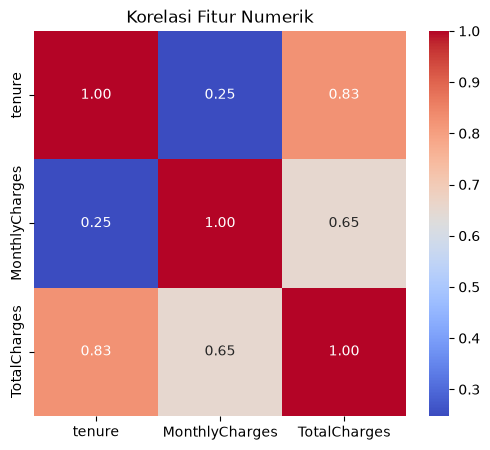

In [6]:
# heatmap korelasi fitur numerik
angka = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
angka['TotalCharges'] = pd.to_numeric(angka['TotalCharges'], errors='coerce')
plt.figure(figsize=(6, 5))
sns.heatmap(angka.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasi Fitur Numerik')
plt.show()

# 2. Preprocessing


In [7]:
# kolom TotalCharges terbaca sebagai teks karena ada 11 baris berisi spasi kosong
print('Baris TotalCharges kosong:', (df['TotalCharges'] == ' ').sum())

# ubah ke angka (yang kosong jadi NaN), lalu isi NaN pakai median
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
print('Missing setelah dibersihkan:', df.isnull().sum().sum())

Baris TotalCharges kosong: 11
Missing setelah dibersihkan: 0


In [8]:
# one-hot encoding buat semua kolom kategorikal
df = pd.get_dummies(df, columns=['gender', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'], drop_first=True)

# ubah target jadi angka: Yes = 1, No = 0, dan buang customerID (cuma id, tidak ada info)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = df.drop(columns=['customerID'])
print('Jumlah fitur akhir:', df.shape[1] - 1)

Jumlah fitur akhir: 30


In [9]:
# pisahkan fitur (X) dan target (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# split 80:20 pakai stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

X_train: (5634, 30)
X_test : (1409, 30)


**Catatan:** ANN juga menghitung penjumlahan berbobot dari fiturnya, jadi fitur yang rentangnya besar (misal TotalCharges ribuan) bisa mendominasi training dan bikin konvergensi lambat/tidak stabil. Makanya fitur di-scaling dulu pakai `StandardScaler`. Scaler cuma di-`fit` ke train set, lalu `transform` ke train dan test, biar tidak data leakage.


In [10]:
# scaling: fit ke train saja, lalu transform keduanya
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print('Rata-rata X_train setelah scaling (harusnya ~0):', round(float(X_train_s.mean()), 2))

Rata-rata X_train setelah scaling (harusnya ~0): -0.0


# 3. Eksperimen Model


## 3.1 ANN dengan Arsitektur Dasar

Bangun MLPClassifier sederhana satu hidden layer sebagai baseline.


In [11]:
# latih ANN baseline: satu hidden layer isi 10 neuron, aktivasi relu
ann_dasar = MLPClassifier(hidden_layer_sizes=(10,), activation='relu',
                          max_iter=300, random_state=42)
ann_dasar.fit(X_train_s, y_train)
print('Selesai training. Iterasi yang dipakai:', ann_dasar.n_iter_)

Selesai training. Iterasi yang dipakai: 300


In [12]:
# prediksi ke test set
pred_dasar = ann_dasar.predict(X_test_s)
print('Akurasi (baseline):', accuracy_score(y_test, pred_dasar))

Akurasi (baseline): 0.7955997161107168


## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan cara neuron mengaktifkan keluarannya dan bikin model bisa belajar pola non-linear. Di sini saya bandingkan relu, tanh, dan logistic dengan arsitektur yang sama.


In [13]:
# latih 3 model dengan arsitektur sama (10,), aktivasi beda
model_aktivasi = {}
for a in ['relu', 'tanh', 'logistic']:
    m = MLPClassifier(hidden_layer_sizes=(10,), activation=a,
                      max_iter=300, random_state=42)
    m.fit(X_train_s, y_train)
    model_aktivasi[a] = m
print('Selesai training 3 model')

Selesai training 3 model


In [14]:
# bandingkan metrik test ketiganya dalam satu tabel
hasil_aktivasi = pd.DataFrame({
    a: [accuracy_score(y_test, m.predict(X_test_s)),
        precision_score(y_test, m.predict(X_test_s)),
        recall_score(y_test, m.predict(X_test_s)),
        f1_score(y_test, m.predict(X_test_s))]
    for a, m in model_aktivasi.items()
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
print(hasil_aktivasi.round(4))

             relu    tanh  logistic
Accuracy   0.7956  0.7906    0.7906
Precision  0.6335  0.6223    0.6254
Recall     0.5455  0.5374    0.5267
F1-Score   0.5862  0.5768    0.5718


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Makin besar/dalam arsitektur ANN, makin besar kapasitas model buat menghafal data training. Di sini saya coba (2,), (5,), (10,), (50,), dan (100, 50) pakai aktivasi terbaik dari eksperimen 3.2.


In [15]:
# coba beberapa ukuran arsitektur, aktivasi pakai relu (terbaik di 3.2)
daftar_arsitektur = [(2,), (5,), (10,), (50,), (100, 50)]
model_arsitektur = {}
for h in daftar_arsitektur:
    m = MLPClassifier(hidden_layer_sizes=h, activation='relu',
                      max_iter=300, random_state=42)
    m.fit(X_train_s, y_train)
    model_arsitektur[str(h)] = m
print('Selesai training', len(model_arsitektur), 'model')

Selesai training 5 model


In [16]:
# hitung akurasi train dan test tiap arsitektur
skor_train, skor_test = [], []
for h in daftar_arsitektur:
    m = model_arsitektur[str(h)]
    skor_train.append(m.score(X_train_s, y_train))
    skor_test.append(m.score(X_test_s, y_test))
    print(f'{h}: train={skor_train[-1]:.4f}, test={skor_test[-1]:.4f}')

(2,): train=0.8060, test=0.7942
(5,): train=0.8140, test=0.7942
(10,): train=0.8193, test=0.7956
(50,): train=0.8408, test=0.7871
(100, 50): train=0.9528, test=0.7459


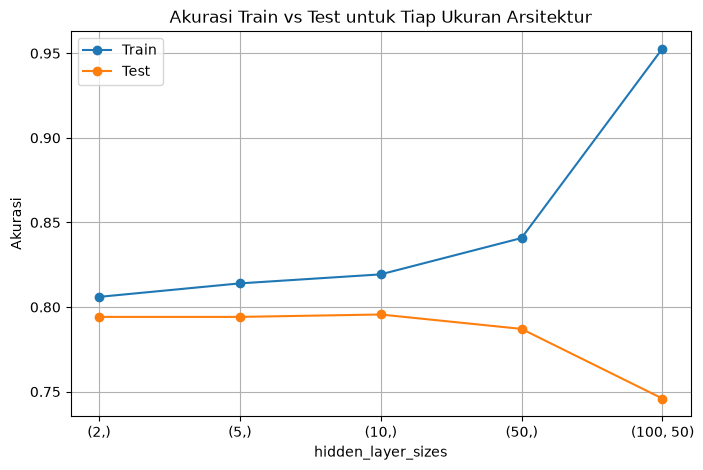

In [17]:
# plot akurasi training vs testing
plt.figure(figsize=(8, 5))
plt.plot([str(h) for h in daftar_arsitektur], skor_train, marker='o', label='Train')
plt.plot([str(h) for h in daftar_arsitektur], skor_test, marker='o', label='Test')
plt.xlabel('hidden_layer_sizes')
plt.ylabel('Akurasi')
plt.title('Akurasi Train vs Test untuk Tiap Ukuran Arsitektur')
plt.legend()
plt.grid(True)
plt.show()
# arsitektur (100, 50) overfitting parah: train tinggi banget tapi test anjlok

# 4. Evaluasi Model


In [18]:
# tabel metrik: model terbaik (relu, (10,)) vs model terbesar ((100, 50)) biar kelihatan efek overfitting-nya
terbaik = model_aktivasi['relu']
terbesar = model_arsitektur['(100, 50)']
pred_baik = terbaik.predict(X_test_s)
pred_besar = terbesar.predict(X_test_s)
hasil = pd.DataFrame({
    'Terbaik (relu, (10,))': [accuracy_score(y_test, pred_baik),
                              precision_score(y_test, pred_baik),
                              recall_score(y_test, pred_baik),
                              f1_score(y_test, pred_baik)],
    'Terbesar ((100, 50))': [accuracy_score(y_test, pred_besar),
                             precision_score(y_test, pred_besar),
                             recall_score(y_test, pred_besar),
                             f1_score(y_test, pred_besar)]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
print(hasil.round(4))

           Terbaik (relu, (10,))  Terbesar ((100, 50))
Accuracy                  0.7956                0.7459
Precision                 0.6335                0.5242
Recall                    0.5455                0.4626
F1-Score                  0.5862                0.4915


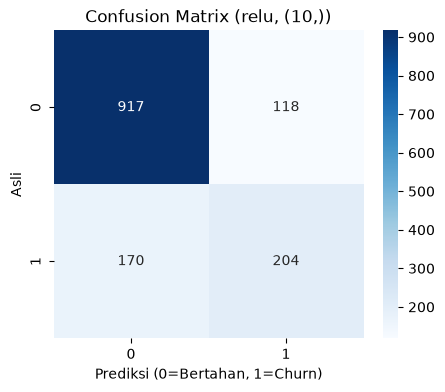

In [19]:
# confusion matrix model terbaik
cm = confusion_matrix(y_test, pred_baik)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (relu, (10,))')
plt.xlabel('Prediksi (0=Bertahan, 1=Churn)')
plt.ylabel('Asli')
plt.show()

Iterasi yang dipakai: 300 dari max_iter=300
Loss akhir: 0.3883


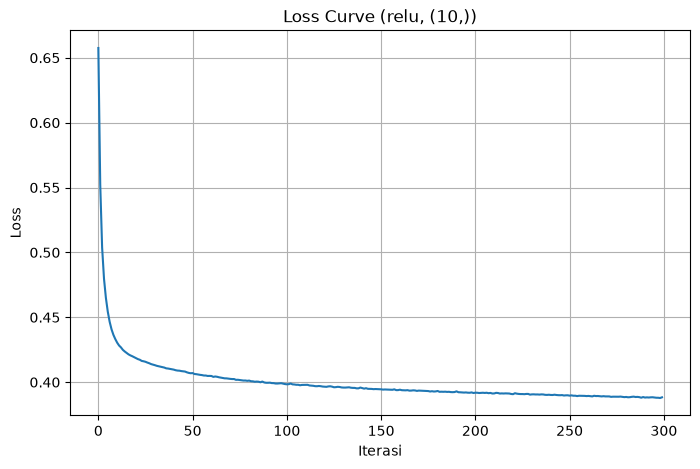

In [20]:
# loss curve model terbaik buat lihat konvergensinya
print('Iterasi yang dipakai:', terbaik.n_iter_, 'dari max_iter=300')
print('Loss akhir:', round(float(terbaik.loss_), 4))

plt.figure(figsize=(8, 5))
plt.plot(terbaik.loss_curve_)
plt.xlabel('Iterasi')
plt.ylabel('Loss')
plt.title('Loss Curve (relu, (10,))')
plt.grid(True)
plt.show()
# loss masih menurun saat max_iter habis, artinya belum konvergen penuh

# 5. Analisis

**Fungsi aktivasi:** relu jadi yang terbaik (akurasi 0,7956) tapi bedanya tipis dengan tanh dan logistic yang sama-sama 0,7906. Precision/recall-nya juga mirip (relu 0,6335/0,5455; tanh 0,6223/0,5374; logistic 0,6254/0,5267). Menurut saya wajar karena dengan satu hidden layer kecil kapasitas ketiganya mirip, dan relu memang biasanya paling aman karena tidak gampang saturasi seperti sigmoid/tanh.

**Eksperimen ukuran arsitektur:** arsitektur kecil (2,), (5,), (10,) hasilnya mirip-mirip (test sekitar 0,794-0,796) dengan train cuma sedikit di atas test, jadi masih sehat. Mulai (50,) gap-nya melebar (train 0,8408 vs test 0,7871), dan di (100, 50) overfitting-nya parah banget: train 0,9528 tapi test anjlok ke 0,7459. Cirinya jelas: garis train naik terus mengikuti kapasitas model, garis test datar lalu turun.

**Loss curve:** model terbaik berhenti di iterasi 300 yang artinya mentok `max_iter`, bukan berhenti karena konvergen. Grafiknya juga masih kelihatan menurun di akhir, jadi model sebenarnya belum konvergen penuh. Kalau loss masih menurun tajam saat max_iter tercapai, solusinya tinggal naikkan `max_iter` (misal 500 atau 1000) atau turunkan `tol`, sambil dicek apakah akurasi test ikut naik atau malah overfitting.


# 6. Kesimpulan dan Saran

**Kesimpulan:** ANN bisa memprediksi churn dengan akurasi sekitar 79,6% (relu, satu hidden layer 10 neuron). Fungsi aktivasi tidak terlalu ngaruh di kasus ini, bedanya cuma ~0,5%. Yang paling ngaruh justru ukuran arsitektur: terlalu besar bikin overfitting parah (train 95% vs test 74,6%). Scaling juga penting karena ANN sensitif sama rentang fitur, dan loss curve menunjukkan model butuh iterasi lebih banyak buat konvergen.

**Saran:** (1) naikkan `max_iter` sampai loss benar-benar konvergen; (2) coba regularisasi `alpha` (L2) atau early stopping biar arsitektur besar tidak overfitting; (3) coba solver lain seperti 'sgd'/'adam' yang beda learning rate, atau tuning pakai GridSearchCV; (4) tangani imbalance churn (26,5%) misalnya dengan class_weight kalau recall kelas churn dirasa kurang.
